<a href="https://colab.research.google.com/github/Le2se0hy/FA_ProAn/blob/main/%ED%95%B8%EC%A6%88%EC%98%A8%EB%A8%B8%EC%8B%A0%EB%9F%AC%EB%8B%9D_4%EC%9E%A5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 핸즈온 머신러닝_4장 [모델 훈련]

가장 간단한 모델부터 시작 → 선형 회귀

이 모데을 훈련시키는 두 가지 방법을 설명
- 닫힌 형태의 방정식을 사용하여 훈련 세트에 가장 잘 맞는 모델 파라미터를 직접 계산
- 경사 하강법이라 불리는 반복적인 최적화 방식을 사용하여 모델 파라미터를 조금씩 바꾸면서 비용 함수를 훈련 세트에 대해 최소화 시킴. 결국 앞의 방법과 동일한 파라미터로 수렴

---
## 4.1 선형 회귀

다음은 1장에서 본 삶의 만족도에 대한 간단한 선형 회귀 모델

$ 삶의 만족도 = θ_0 + θ_1 × 1인당GDP $

이 모델은 입력 특성인 1인당 GDP에 대한 선형 함수이다. 더 일반적으로 선형 모델은 밑의 식처럼 입력 특성의 가중치 합과 편향(=절편)이라는 상수를 더해 예측을 만듬

$ ŷ = θ_0 + θ_1x_1 + θ_2x_2 + … + θ_nx_n $
- ŷ : 예측값
- n : 특성의 수
- $x_i$ : i번째 특성
- $θ_j$ : j번째 모델 파라미터 (편향 $θ_0$과 특성의 가중치 $θ_1,θ_2,θ_3, …θ_n$을 포함)

밑과 같이 벡터 형태로 더 간단하게 쓸 수 있음

$ ŷ = h_θ(x) = θ⋅x $

- $h_θ$ : 모델 파라미터 θ를 사용한 가설 함수
- $θ$ : 편향 $θ_0$과 $θ_1$에서 $θ_n$까지의 특성 가중치를 담은 모델의 파라미터 벡터
- $x$ : $x_0$에서 $x_n$가지 담은 샘플의 특성 벡터. $x_0$은 항상 1
- $θ⋅x$ : 벡터 $θ$와 $x$의 점곱 (= $θ_0x_0 + θ_1x_1 + θ_2x_2 + … + θ_nx_n$)




모델을 훈련시킨다는 것은 모델이 훈련 세트에 가장 잘 맞도록 모델 파라미터를 설정하는 것

이를 위헤 먼저 모델이 훈련 데이터에 얼마나 잘 들어맞는지 측정해야 함.

회귀에서 가장 널리 사용되는 성능 측정 지표는 RMSE(평균 제곱근 오차)이다.
→ 선형 회귀 모델을 훈련시키려면 RMSE를 최소화하는 0을 찾아야함

실제로는 RMSE보다 MSE(평균 제곱 오차)를 최소화하는 것이 같은 결과를 내면서 더 간단

훈련 세트 X에 대한 선형 회귀 가설 h_θ의 MSE는 밑과 같이 계산함

$ MSE(\mathbf{X},h_\theta) = \frac{1}{m}\sum_{i=1}^{m}(\mathbf{θ}^T\mathbf{x}^{(i)} - y^{(i)})^2 $

이 표기법의 대부분은 2장에서 설명했다(고 적혀있지만 2장 어디서 배웠는지 사실 기억이 나지 않는다)

딱 하나의 차이는 모델이 파라미터 벡터θ를 가진다는 것을 명확히 하려고 h 대신 h_θ를 사용한 것뿐이다. 앞으로 간단히 MSE(Θ)를 사용하겠음




### 4.1.1 정규 방정식

**정규 방정식** : 비용 함수를 최소화하는 θ 값을 찾기 위한 해석적인 방법이 있음. 다른 말로 하면 결과를 바로 얻을 수 있는 수학 공식.

$ θ̂ = (X^TX)^{-1}X^Ty  $

- $θ̂ $ : 비용 함수를 최소화하는 θ 값
- $y$ : $y^{(1)}$부터 $y^{(m)}$까지 포함하는 타깃 벡터

이 공식을 테스트하기 위해 선형처럼 보이는 데이터를 생성



In [ ]:
import numpy as np

np.random.seed(42)  # 동일하게 재현되도록 하기 위해 지정함
m = 100  # 샘플 개수
X = 2 * np.random.rand(m, 1)  # 열 벡터
y = 4 + 3 * X + np.random.randn(m, 1)  #열 벡터

그럼 이제 정규 방정식을 사용해 θ̂ 을 계산해보겠다.

넘파이 선형대수 모듈(np.linalg)에 있는 inv() 함수를 사용해 역행렬을 계산하고 dot() 메서드를 사용해 행렬 곱셈을 함



In [ ]:
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X)  # 각 샘플에 xθ = 1을 추가함
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

theta_best

array([[4.21509616],
       [2.77011339]])

$θ_0$= 4.125 와 $θ_1$= 2.770 대신 $θ_0$= 4 와 $θ_1$= 3을 기대했지만 잡음 때문에 원래 함수의 파라미터를 정확하게 재현하지 못했음

데이터셋이 작고 잡음이 많을수록 정확한 값을 얻기 힘듬

θ̂ 을 사용해 예측을 해보자

In [ ]:
X_new = np.array([[0],[2]])
X_new_b = add_dummy_feature(X_new)
y_predict = X_new_b @ theta_best
y_predict

array([[4.21509616],
       [9.75532293]])

모델의 예측을 그래프로 나타내보자

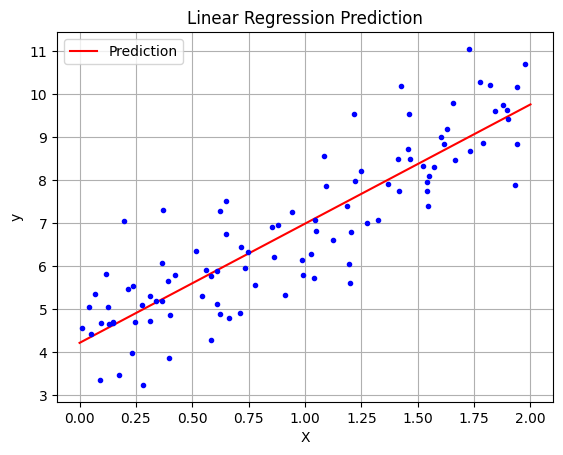

In [ ]:
import matplotlib.pyplot as plt

plt.plot(X_new, y_predict, "r-", label="Prediction")
plt.plot(X, y, "b.")
# 레이블, 축 , 그리드 범례를 추가
plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression Prediction")
plt.grid(True)
plt.legend()
plt.show()

사이킷런에서 선형 회귀를 수행하는 것은 비교적 간단하다.

In [ ]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([4.21509616]), array([[2.77011339]]))

In [ ]:
lin_reg.predict(X_new)

array([[4.21509616],
       [9.75532293]])

사이킷런은 특성의 가중치(coef_)와 편향(intercept_)을 분리하여 저장함

LinearRegression 클래스는 scipy.linalg.lstsq() 함수('최소 제곱'에서 이름을 따왔음)를 기반으로 함. 다음과 같이 이 함수를 직접 호출할 수 있음

In [ ]:
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6)
theta_best_svd

array([[4.21509616],
       [2.77011339]])

이 함수는 $ θ̂  = X^{+}y $를 계산한다.

$ X^{+}$는 $X$의 유사역행렬이다.

np.linalg.pinv() 함수를 사용해 유사역행렬을 직접 구할 수 있다.



In [ ]:
np.linalg.pinv(X_b) @ y

array([[4.21509616],
       [2.77011339]])

유사역행렬 자체는 **특잇값 분해**(SVD)라 부르는 표준 행렬 분해 기법을 사용해 계산됨.

SVD는 훈련 세트 행렬 X를 3개의 행렬 곱셉 $UΣVᵀ$로 분해함

유사역행렬은 $X^{+} = VΣUᵀ$ 로 계산됨. $Σ^+$를 계산하기 위해 알고리즘이 Σ를 먼저 수한 다으므 어떤 낮은 임곗값보다 작은 모둔 수를 0으로 바꿈.

그 다음 0이 아닌 모든 값을 역수로 치환함. 마지막으로 만들어진 행렬을 전치함.
정류 방정식을 계산하는 것보다 이 방식이 훨씬 효율적이고 극단적인 경우도 처리 가능

실제로 m<n이거나 어떤 특성이 중복되어 행렬 XᵀX의 역행렬이 없다면(= 특이 행렬이라면) 정규 방정식이 작동하지 않음. 하지만 유사역행렬을 항상 구할 수 있음

### 4.1.2 계산 복잡도

정규 방정식은 (n+1)×(n+1) 크기의 XᵀX의 역행렬을 계산한다 (n은 특성 수)

역행렬을 계산하는 계산 복잡도는 일반적으로 O(n^2.4)에서 O(n^3) 사이이다.

→ 다시 말해 특성 수가 두 배로 늘어나면 계산 시간이 대략 5.3에서 8배로 증가함

사이킷런의 LinearRegression 클래스가 사용하는 SVD 방법은 약 O(n^2)이다.

→ 특성의 개수가 두 배로 늘어나면 계산 시간은 대략 4배가 됨.

---
## 4.2 경사 하강법

경사 하강법(GD)은 여러 종류의 문제에서 최적의 해법을 찾을 수 있는 일반적인 최적화 알고리즘이다.

경사 하강법의 기본 아이디어는 비용 함수를 최소화하기 위해 반복해서 파라미터를 조정해감

1. 파라미터 벡터 θ 에 대해 비용 함수의 현재 그래디언트를 계산함
2. 그래디언트가 감소하는 방향으로 진행
3. 그래디언트가 0이 되면 최솟값에 도달한것임

구체적으로 본다면 θ를 임의의 값으로 시작해서(**랜덤 초기화**) 한 번에 조금씩 비용 함수(ex) MSE)가 감소되는 방향으로 진행하여 알고리즘이 최솟값에 수렴할 떄까지 점진적으로 향상시킴

경사 하강법에서 중요한 파라미터는 스템의 크기 = 학습률 하이퍼파라미터로 결정

- 학습률이 너무 작으면 알고리즘이 수렴하기 위해 반복을 많이 진행해야해서 시간이 오래 걸림
- 학습률이 너무 크면 골짜기를 가로질러 이전보다 더 높은 곳으로 올라가 알고리즘을 더 큰 값으로 발산하게 됨

모든 비용 함수가 그릇형태가 아니기에 여러 지형이 있으면 최솟값으로 수렴하기 매우 어려움

→ 전역 최솟값 이전에 지역 최솟값이 있는 상태에서 알고리즘을 시작하면 지역 최솟값에 수렴함

다행히 선형 회귀를 위한 MSE 비용 함수는 곡선에서 어떤 두 점을 선택해 선을 그어도 곡선을 가로지르지 않는 볼록 함수임

→ 지역 최솟값 X  전역 최솟값만 있음

